<a href="https://colab.research.google.com/github/hoangchaugiahan/FUZZYLOGIC/blob/main/Palm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,Dropout

In [35]:
import pandas as pd
from keras.utils import to_categorical # Import to_categorical

data = '/content/HandInfo.csv'
df = pd.read_csv(data)
print(df.head())
import keras
(x_train, y_train),(x_test,y_test)=keras.datasets.cifar10.load_data()
assert x_train.shape==(50000,32,32,3)
assert x_test.shape==(10000,32,32,3)
assert y_train.shape==(50000,1)
assert y_test.shape==(10000,1)
y_train=to_categorical(y_train,102) # Now to_categorical is defined
y_test=to_categorical(y_test,102)

   id  age gender skinColor  accessories  nailPolish  aspectOfHand  \
0   0   27   male      fair            0           0  dorsal right   
1   0   27   male      fair            0           0  dorsal right   
2   0   27   male      fair            0           0  dorsal right   
3   0   27   male      fair            0           0  dorsal right   
4   0   27   male      fair            0           0  dorsal right   

          imageName  irregularities  
0  Hand_0000002.jpg               0  
1  Hand_0000003.jpg               0  
2  Hand_0000004.jpg               0  
3  Hand_0000005.jpg               0  
4  Hand_0000006.jpg               0  


In [46]:
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Dropout, MaxPooling2D, Conv2D, Flatten # import MaxPooling2D, Conv2D, Flatten here
from tensorflow.keras.optimizers import Adam # import Adam here
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)



In [47]:
model=Sequential([
    Dense(1024,activation='relu',input_shape=(32*32*3,)),
    Dense(512,activation='relu'),
    Dense(256,activation='relu'),
    Dense(128,activation='relu'),
    Dense(102,activation='sigmoid')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 83ms/step - accuracy: 0.2028 - loss: 64.0869 - val_accuracy: 0.3121 - val_loss: 1.9806
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 72ms/step - accuracy: 0.3235 - loss: 1.9559 - val_accuracy: 0.3212 - val_loss: 1.9003
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 74ms/step - accuracy: 0.3512 - loss: 1.8355 - val_accuracy: 0.3581 - val_loss: 1.8235
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.3728 - loss: 1.7652 - val_accuracy: 0.3790 - val_loss: 1.7362
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.3790 - loss: 1.7365 - val_accuracy: 0.3767 - val_loss: 1.7613
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 74ms/step - accuracy: 0.3926 - loss: 1.6990 - val_accuracy: 0.3913 - val_loss: 1.7263
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.3996 - loss: 1.6847 - val_accuracy: 0.3877 - val_loss: 1.6799
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 76ms/step - accuracy: 0.3995 - loss: 1.6808 -

FileNotFoundError: [Errno 2] No such file or directory: '/content/palm.png'

In [49]:
t_loss,test_acc=model.evaluate(x_test,y_test)
print('test_acc:%.2f'%(test_acc*100))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4267 - loss: 1.6172
test_acc:42.38


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
tien doan la:  6


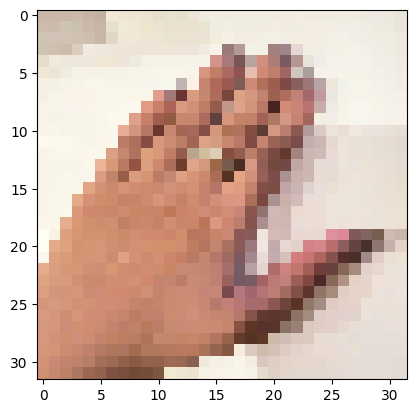

In [48]:
img_path = "/content/palm.jpg"
img = load_img(img_path, target_size=(32, 32))
plt.imshow(img)
img_array = img_to_array(img) / 255.0
img_flatten = img_array.reshape(1, 32 * 32 * 3)
prediction = model.predict(img_flatten)
print('tien doan la: ', np.argmax(prediction))